In [1]:
###############
## FUNCTIONS ##
###############

def normalise(x):
    return (x - x.min())/(x.max() - x.min())

def bin_y_along_x(arr_x, x_index, arr_y, y_index):
    x_unique = np.unique(arr_x[:,x_index])
    y_binned = []
    for x_unique_ in x_unique:
        s = np.argwhere(arr_x[:,x_index] == x_unique_)
        y_binned += [np.mean(arr_y[s,y_index])]
    y_binned = np.array(y_binned)
    return x_unique, y_binned  

def collapse_columns_2Darray_to_string(arr, sep=""):
    """
    """
    arr_str = []
    for arr_ in arr:
        arr_ = [arr__ for arr__ in arr_.astype(str)]
        arr_ = sep.join(arr_)
        arr_str += [arr_]
    return np.array(arr_str)
    
#
###

In [2]:
##############
## INITIATE ##
##############

## Imports
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

## Parameters
# pwd = "/Users/willembonnaffe/Documents/Academia/Projects/PAW-MIL-2D-PPCG/outputs/PPCG_MQ_SmallMediumNozeroNew_256_SingleTask-V20240806/"
# pwd = "/Users/willembonnaffe/Documents/Academia/Projects/PAW-MIL-2D-PPCG/outputs/PPCG_MQ_SmallMediumNozeroNew_256_MultiTask-V20240806/"

#
###

In [3]:
#################
## FORMAT DATA ##
#################

## Load data 
pwd = "/Users/willembonnaffe/Documents/Academia/Projects/PAW-MIL-2D-PPCG/outputs/PPCG_MQ_SmallMediumNozeroNew_256_MultiTask_Augmented_p1_unique/"
# pwd = "/Users/willembonnaffe/Documents/Academia/Projects/PAW-MIL-2D-PPCG/outputs/PPCG_MQ_SmallMediumNozeroNew_256_MultiTask/"
pti = pwd + "hypertrain_fold_1/"
ht = pickle.load(open(pti + "obj_hypertrain_list.pkl", "rb"))
# headers: (selected_training_fold, repeat, batch_size, num_epochs, learn_rate, train_loss, val_loss, val_loss)

## Format to array
hp = []
train = []
val = []
test = []
for ht_ in ht:
    hp += [ht_[0:5]]
    train += [ht_[5]]
    val += [ht_[6]]
    test += [ht_[7]]
hp_1 = np.array(hp)
train_1 = np.array(train)
val_1 = np.array(val)
test_1 = np.array(test)

## Load data 
pwd = "/Users/willembonnaffe/Documents/Academia/Projects/PAW-MIL-2D-PPCG/outputs/PPCG_MQ_SmallMediumNozeroNew_256_MultiTask_Augmented_p1_unique/"
pti = pwd + "hypertrain_fold_4/"
ht = pickle.load(open(pti + "obj_hypertrain_list.pkl", "rb"))
# headers: (selected_training_fold, repeat, batch_size, num_epochs, learn_rate, train_loss, val_loss, val_loss)

## Format to array
hp = []
train = []
val = []
test = []
for ht_ in ht:
    hp += [ht_[0:5]]
    train += [ht_[5]]
    val += [ht_[6]]
    test += [ht_[7]]
hp_2 = np.array(hp)
train_2 = np.array(train)
val_2 = np.array(val)
test_2 = np.array(test)

#
###

In [4]:
#####################
## MODEL SELECTION ##
#####################

## Compute unique combinations of HPs
hp_keys = collapse_columns_2Darray_to_string(hp_1[:,2:5], sep="_")
hp_keys_unique = np.unique(hp_keys)
hp_set_index = np.arange(len(hp_keys_unique))+1
hp_keys_1 = hp_keys

#
###

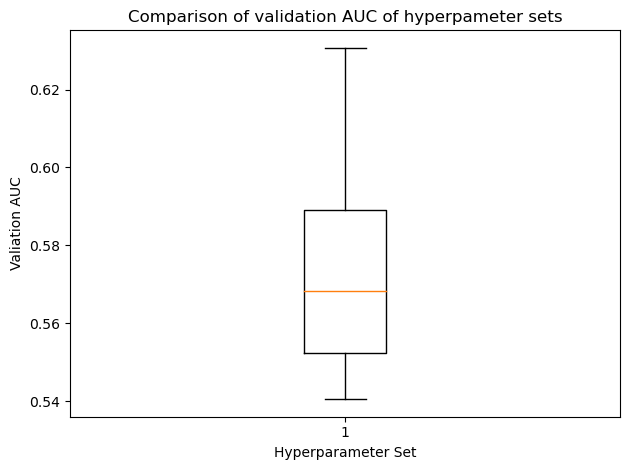

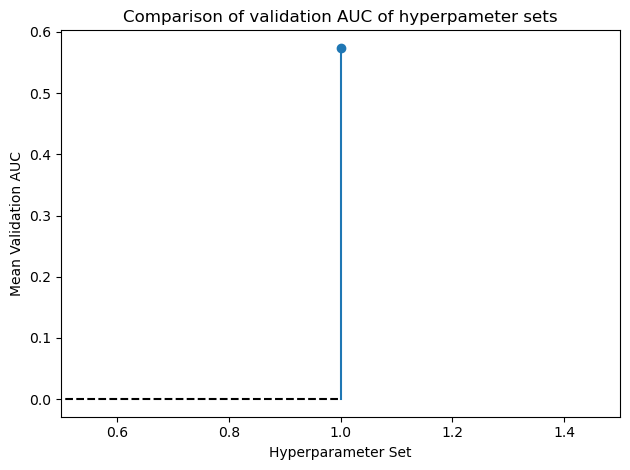

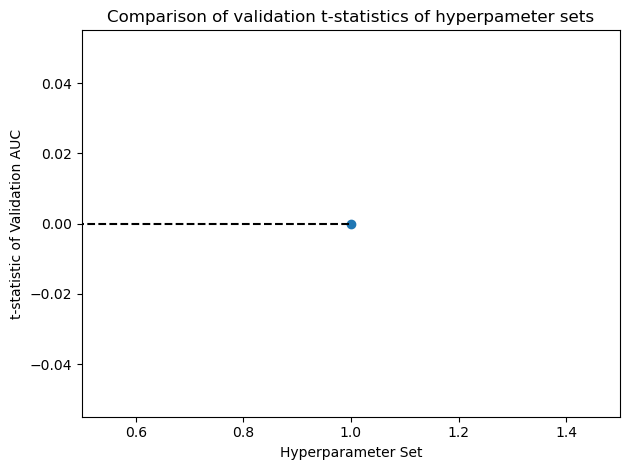

The best hyperparameter set is: 1
HP star is: 8.0_16.0_0.001


In [5]:
###############################
## HYPERPARAMETERS SELECTION ##
###############################

## Slice1
target_arr = val_1

## Assemble data
x_data = []
y_data = []
for hp_keys_unique_ in hp_keys_unique:
    s = np.argwhere(hp_keys == hp_keys_unique_)
    x_data += [hp_keys_unique_]
    y_data += [target_arr.mean(1)[s].flatten()]

## Remove NaNs
y_data = [arr[~np.isnan(arr)] for arr in y_data]

## Boxplot
plt.boxplot(y_data)

## Graphical parameters
plt.xlabel("Hyperparameter Set")
plt.ylabel("Valiation AUC")
plt.title("Comparison of validation AUC of hyperpameter sets")
plt.tight_layout()
plt.show()
plt.close()

## Compute mean AUC
auc_list = [np.mean(y_) for y_ in y_data]

## Visualise statistic
plt.scatter(hp_set_index, auc_list)
plt.plot([0,len(hp_set_index)], [0,0], linestyle="--", color="black")
for i in range(len(auc_list)): 
    plt.plot([hp_set_index[i],hp_set_index[i]], [0,auc_list[i]])

## Graphical parameters
plt.xlim(1-0.5,len(hp_set_index)+0.5)
plt.xlabel("Hyperparameter Set")
plt.ylabel("Mean Validation AUC")
plt.title("Comparison of validation AUC of hyperpameter sets")
plt.tight_layout()
plt.show()
plt.close()

## Compute t-statistic
t_list = [(np.mean(y_)-np.mean(y_data))/np.std(y_) for y_ in y_data]

## Visualise statistic
plt.scatter(hp_set_index, t_list)
plt.plot([0,len(hp_set_index)], [0,0], linestyle="--", color="black")
for i in range(len(t_list)): 
    plt.plot([hp_set_index[i],hp_set_index[i]], [0,t_list[i]])

## Graphical parameters
plt.xlim(1-0.5,len(hp_set_index)+0.5)
plt.xlabel("Hyperparameter Set")
plt.ylabel("t-statistic of Validation AUC")
plt.title("Comparison of validation t-statistics of hyperpameter sets")
plt.tight_layout()
plt.show()
plt.close()

## Best HP set
hp_star_index = np.argmax(t_list)
hp_star = hp_keys_unique[hp_star_index]
print(f"The best hyperparameter set is: {hp_star_index + 1}")
print(f"HP star is: {hp_star}")

## Save
hp_star_1 = hp_star

#
###

In [6]:
#####################
## MODEL SELECTION ##
#####################

## Compute unique combinations of HPs
hp_keys = collapse_columns_2Darray_to_string(hp_2[:,2:5], sep="_")
hp_keys_unique = np.unique(hp_keys)
hp_set_index = np.arange(len(hp_keys_unique))+1
hp_keys_2 = hp_keys

#
###

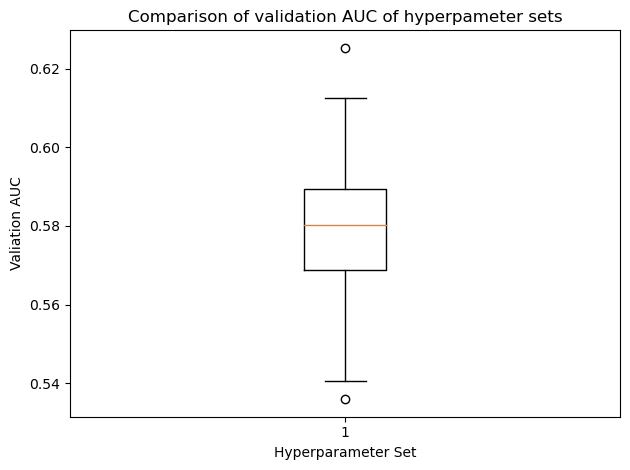

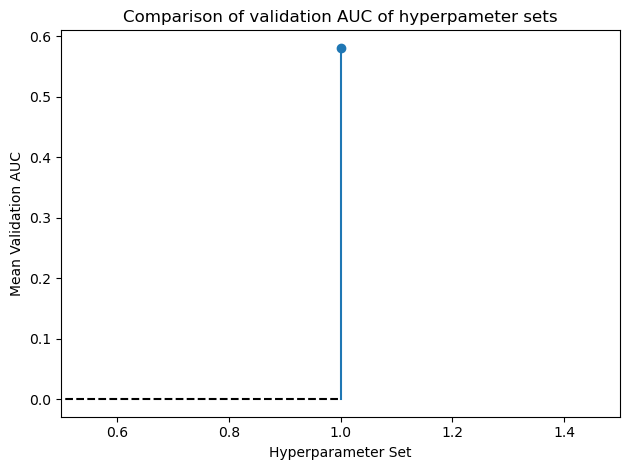

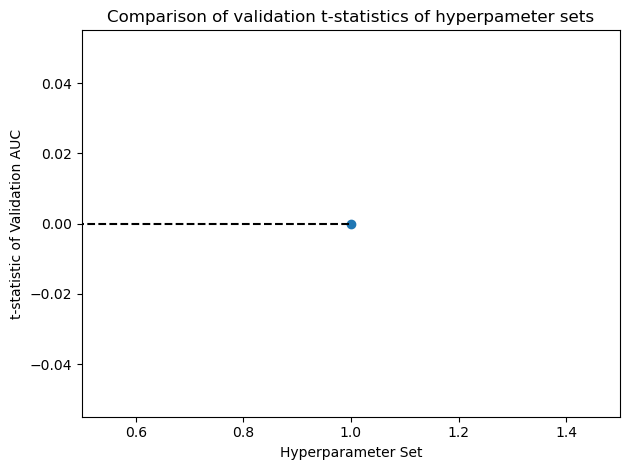

The best hyperparameter set is: 1
HP star is: 8.0_16.0_0.001


In [7]:
###############################
## HYPERPARAMETERS SELECTION ##
###############################

## Slice1
target_arr = val_2

## Assemble data
x_data = []
y_data = []
for hp_keys_unique_ in hp_keys_unique:
    s = np.argwhere(hp_keys == hp_keys_unique_)
    x_data += [hp_keys_unique_]
    y_data += [target_arr.mean(1)[s].flatten()]

## Remove NaNs
y_data = [arr[~np.isnan(arr)] for arr in y_data]

## Boxplot
plt.boxplot(y_data)

## Graphical parameters
plt.xlabel("Hyperparameter Set")
plt.ylabel("Valiation AUC")
plt.title("Comparison of validation AUC of hyperpameter sets")
plt.tight_layout()
plt.show()
plt.close()

## Compute mean AUC
auc_list = [np.mean(y_) for y_ in y_data]

## Visualise statistic
plt.scatter(hp_set_index, auc_list)
plt.plot([0,len(hp_set_index)], [0,0], linestyle="--", color="black")
for i in range(len(auc_list)): 
    plt.plot([hp_set_index[i],hp_set_index[i]], [0,auc_list[i]])

## Graphical parameters
plt.xlim(1-0.5,len(hp_set_index)+0.5)
plt.xlabel("Hyperparameter Set")
plt.ylabel("Mean Validation AUC")
plt.title("Comparison of validation AUC of hyperpameter sets")
plt.tight_layout()
plt.show()
plt.close()

## Compute t-statistic
t_list = [(np.mean(y_)-np.mean(y_data))/np.std(y_) for y_ in y_data]

## Visualise statistic
plt.scatter(hp_set_index, t_list)
plt.plot([0,len(hp_set_index)], [0,0], linestyle="--", color="black")
for i in range(len(t_list)): 
    plt.plot([hp_set_index[i],hp_set_index[i]], [0,t_list[i]])

## Graphical parameters
plt.xlim(1-0.5,len(hp_set_index)+0.5)
plt.xlabel("Hyperparameter Set")
plt.ylabel("t-statistic of Validation AUC")
plt.title("Comparison of validation t-statistics of hyperpameter sets")
plt.tight_layout()
plt.show()
plt.close()

## Best HP set
hp_star_index = np.argmax(t_list)
hp_star = hp_keys_unique[hp_star_index]
print(f"The best hyperparameter set is: {hp_star_index + 1}")
print(f"HP star is: {hp_star}")

## Save
hp_star_2 = hp_star

#
###

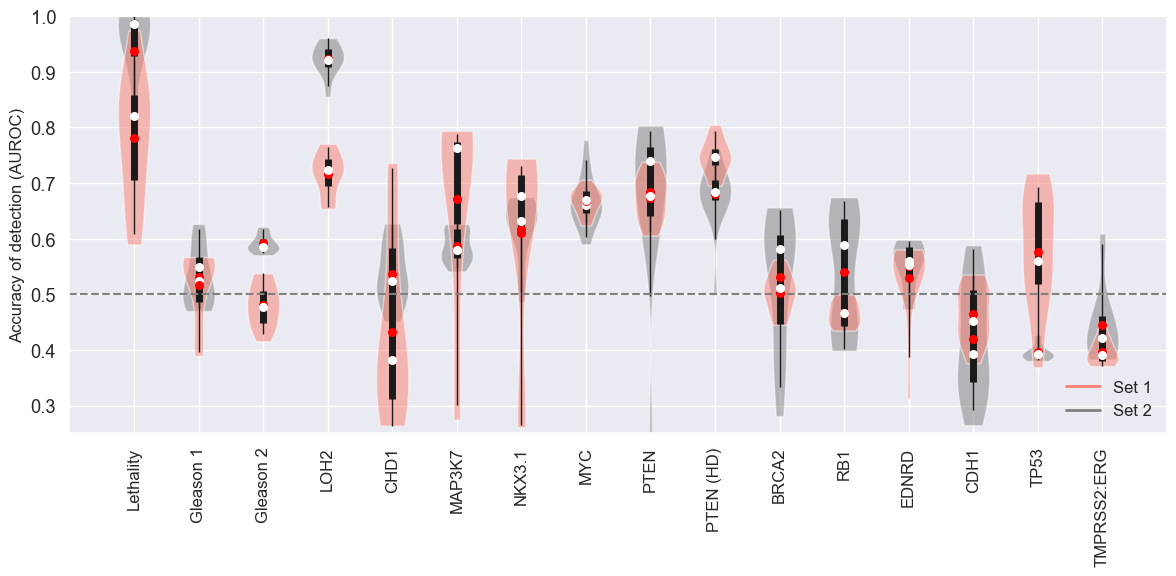

In [16]:
############################
## VISUALISATIONS OF AUCs ##
############################

## Setup
from matplotlib.lines import Line2D

## Subset results for best models
s_1 = np.argwhere(hp_star_1 == hp_keys_1)
# s_1 = np.argwhere("8.0_16.0_0.001" == hp_keys) # manual selection
test_1_star = test_1[s_1].squeeze()
#
s_2 = np.argwhere(hp_star_2 == hp_keys_2)
# s_2 = np.argwhere("16.0_32.0_0.001" == hp_keys) # manual selection
test_2_star = test_2[s_2].squeeze()

## Column vector for single label predictions
if len(test_1_star.shape) == 1:
    test_1_star = test_1_star.reshape(-1,1)
if len(test_2_star.shape) == 1:
    test_2_star = test_2_star.reshape(-1,1)

# Create a new figure with a specific size
plt.figure(figsize=(12, 6))  # Width: 8 inches, Height: 6 inches
fontsize = 12

## Label 2
data = [test_1_star[:,i] for i in range(test_1_star.shape[1])]
x_offset = 0.0
x = [1 + x_offset + i for i in range(len(data))]
parts = plt.violinplot(
        data, positions=x, showmeans=False, showmedians=False,
        showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor('grey')
    # pc.set_edgecolor('black')
    pc.set_alpha(0.5)
q05, quartile1, medians, quartile3, q95 = np.percentile(data, [5, 25, 50, 75, 95], axis=1)
inds = np.arange(1, len(medians) + 1) + x_offset
means = np.mean(data, axis=1)
plt.scatter(inds, means, marker='o', color='red', s=30, zorder=3)
plt.scatter(inds, medians, marker='o', color='white', s=30, zorder=3)
plt.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)
plt.vlines(inds, q05, q95, color='k', linestyle='-', lw=1)

## Label 1
data = [test_2_star[:,i] for i in range(test_2_star.shape[1])]
# data = [test_1_star[:,i] for i in range(test_1_star.shape[1])]
x_offset = 0.0
x = [1 + x_offset + i for i in range(len(data))]
parts = plt.violinplot(
        data, positions=x, showmeans=False, showmedians=False,
        showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor('salmon')
    # pc.set_edgecolor('black')
    pc.set_alpha(0.5)
q05, quartile1, medians, quartile3, q95 = np.percentile(data, [5, 25, 50, 75, 95], axis=1)
inds = np.arange(1, len(medians) + 1) + x_offset
means = np.mean(data, axis=1)
plt.scatter(inds, means, marker='o', color='red', s=30, zorder=3)
plt.scatter(inds, medians, marker='o', color='white', s=30, zorder=3)
plt.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)
plt.vlines(inds, q05, q95, color='k', linestyle='-', lw=1)

## Add line at 0.5
plt.axhline(y=0.5, linestyle='--', color='gray')

## Legend
custom_lines = [Line2D([0], [0], color='salmon', lw=2), Line2D([0], [0], color='grey', lw=2)]
plt.legend(custom_lines, ['Set 1', 'Set 2'], loc='lower right', frameon=False, fontsize=fontsize)

## Graphical parameters
labels = [
    "Lethality",
    "Gleason 1",
    "Gleason 2",    
    "LOH2",
    "CHD1",
    "MAP3K7",
    "NKX3.1",
    "MYC",
    "PTEN",
    "PTEN (HD)",
    "BRCA2",
    "RB1",
    "EDNRD",
    "CDH1",
    "TP53",
    "TMPRSS2:ERG"
    ]
sns.set(font_scale=1.2)
plt.xticks(np.arange(1, len(labels) + 1), labels=labels, rotation='vertical', size=fontsize)
plt.xlabel("")
plt.ylabel("Accuracy of detection (AUROC)", size=fontsize)
plt.ylim(0.25,1)
plt.xlim(0,17)
# plt.title("Comparison of test AUC")
plt.tight_layout()
plt.show()
plt.close()

#
###